# 01_EDA.ipynb – Exploratory Data Analysis (EDA) on NHL Data

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 1️⃣ Load the Data

### Load NHL dataset
We start by loading the cleaned NHL dataset from `data/processed/nhl_data_clean.csv`.

In [3]:
# Paths
RAW_DATA_PATH = os.path.join("..", "data", "processed", "nhl_data_clean.csv")

# Load the data
df = pd.read_csv(RAW_DATA_PATH)
df.head()

,Team Name,Year,Wins,Losses,OT Losses,Win %,Goals For (GF),Goals Against (GA),Goal Difference,+ / -
0,Boston Bruins,1990,44,24,0.0,0.550,299,264,35,35
1,Buffalo Sabres,1990,31,30,0.0,0.388,292,278,14,14
2,Calgary Flames,1990,46,26,0.0,0.575,344,263,81,81
3,Chicago Blackhawks,1990,49,23,0.0,0.613,284,211,73,73
4,Detroit Red Wings,1990,34,38,0.0,0.425,273,298,-25,-25


## 2️⃣ Data Overview

### Data Overview
Check the shape, columns, data types, and missing values to understand the dataset structure.

In [4]:
# Shape and info
print("Data Shape:", df.shape)
print("\nData Info:")
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Data Shape: (582, 10)

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Team Name           582 non-null    str    
 1   Year                582 non-null    int64  
 2   Wins                582 non-null    int64  
 3   Losses              582 non-null    int64  
 4   OT Losses           582 non-null    float64
 5   Win %               582 non-null    float64
 6   Goals For (GF)      582 non-null    int64  
 7   Goals Against (GA)  582 non-null    int64  
 8   Goal Difference     582 non-null    int64  
 9   + / -               582 non-null    int64  
dtypes: float64(2), int64(7), str(1)
memory usage: 45.6 KB

Missing Values:
Team Name             0
Year                  0
Wins                  0
Losses                0
OT Losses             0
Win %                 0
Goals For (GF)        0
Goals Against (GA)    0
Goal Difference 

## 3️⃣ Descriptive Statistics

### Descriptive Statistics
Get basic statistics for numeric columns to understand ranges, mean, std, min, max, etc.

In [5]:
df.describe()

,Year,Wins,Losses,OT Losses,Win %,Goals For (GF),Goals Against (GA),Goal Difference,+ / -
count,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000
mean,2000.907216,36.943299,32.353952,4.589347,0.458519,234.063574,234.063574,0.000000,0.000000
std,6.330674,8.926081,8.411439,4.605402,0.102237,40.548915,42.510718,45.277458,45.277458
min,1990.000000,9.000000,11.000000,0.000000,0.119000,115.000000,115.000000,-196.000000,-196.000000
25%,1996.000000,31.000000,27.000000,0.000000,0.390000,211.000000,207.000000,-27.000000,-27.000000
50%,2001.000000,38.000000,31.000000,4.000000,0.463000,231.000000,232.500000,4.000000,4.000000
75%,2007.000000,43.000000,37.000000,8.000000,0.534000,254.000000,258.750000,31.000000,31.000000
max,2011.000000,62.000000,71.000000,18.000000,0.756000,369.000000,414.000000,144.000000,144.000000


## 4️⃣ Distribution of Wins

### Wins Distribution
Visualize how wins are distributed across all teams and seasons.

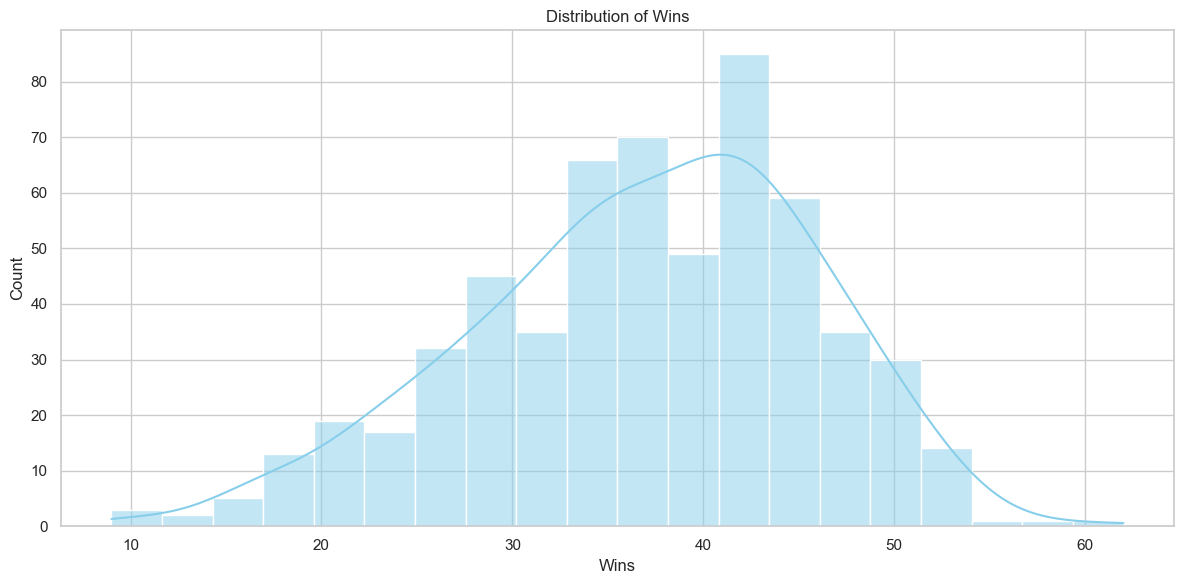

In [7]:
# Set style
sns.set(style="whitegrid")

# Ensure final folder exists
FINAL_DATA_PATH = os.path.join("..", "data", "final")
os.makedirs(FINAL_DATA_PATH, exist_ok=True)

# Plot Wins distribution
plt.figure(figsize=(12,6))
sns.histplot(df['Wins'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Wins")
plt.xlabel("Wins")
plt.ylabel("Count")
plt.tight_layout()

# Save plot safely
plt.savefig(os.path.join(FINAL_DATA_PATH, "wins_distribution.png"))
plt.show()

## 5️⃣ Wins vs Goal Difference

### Wins vs Goal Difference
Visualize the relationship between Wins and Goal Difference to check correlation.

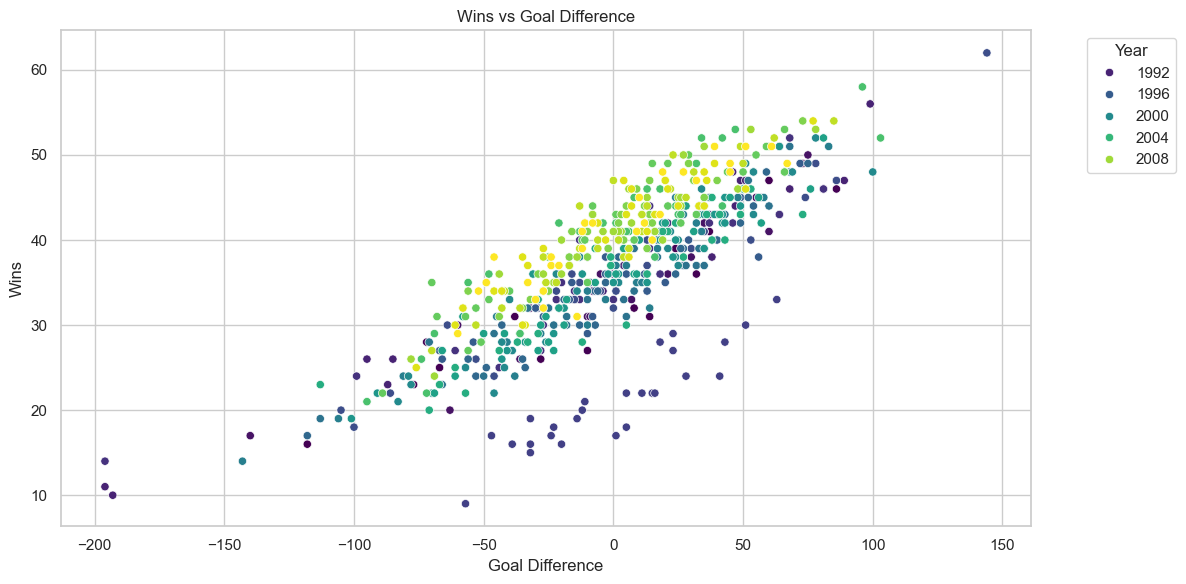

In [9]:
# Set style
sns.set(style="whitegrid")

# Ensure final folder exists
FINAL_DATA_PATH = os.path.join("..", "data", "final")
os.makedirs(FINAL_DATA_PATH, exist_ok=True)

# Scatter plot: Wins vs Goal Difference
plt.figure(figsize=(12,6))
sns.scatterplot(x='Goal Difference', y='Wins', data=df, hue='Year', palette='viridis')
plt.title("Wins vs Goal Difference")
plt.xlabel("Goal Difference")
plt.ylabel("Wins")
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save plot safely
plt.savefig(os.path.join(FINAL_DATA_PATH, "wins_vs_goal_difference.png"))
plt.show()

## 6️⃣ Correlation Heatmap

### Correlation Heatmap
Check correlations between numeric columns.

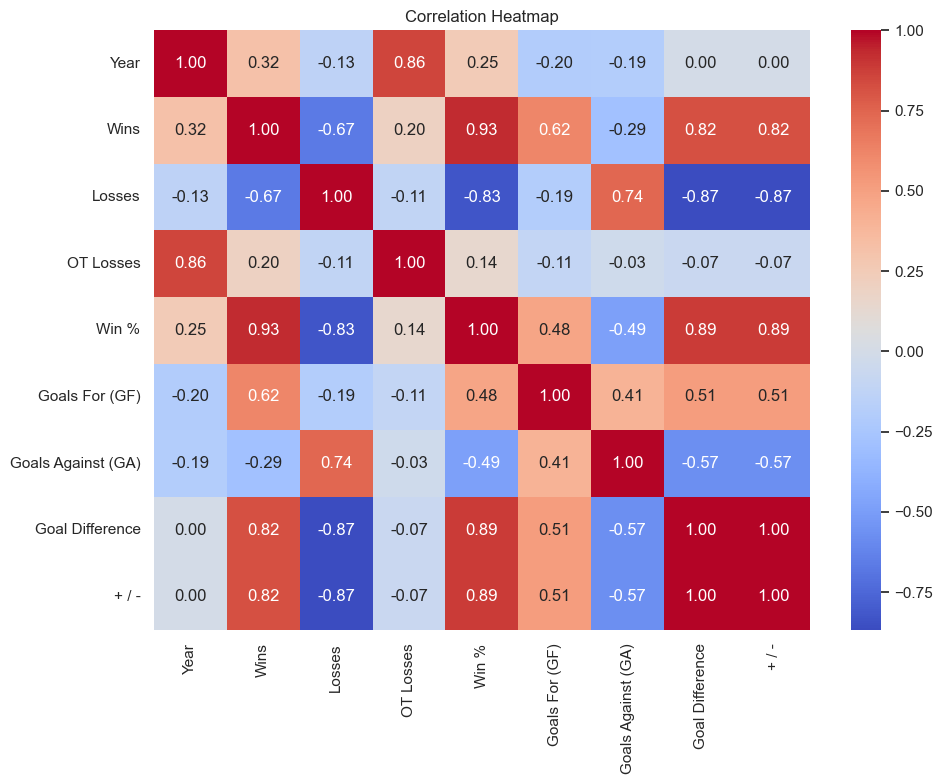

In [12]:
# Set style
sns.set(style="whitegrid")

# Ensure final folder exists
FINAL_DATA_PATH = os.path.join("..", "data", "final")
os.makedirs(FINAL_DATA_PATH, exist_ok=True)

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()

# Save plot safely
plt.savefig(os.path.join(FINAL_DATA_PATH, "correlation_heatmap.png"))
plt.show()

## 7️⃣ Yearly Trends

### Yearly Trends
Analyze the trends of Wins and Goals over years.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12732\4089350740.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Year', y='Wins', data=df, ci=None, label='Wins')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12732\4089350740.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Year', y='Goals For (GF)', data=df, ci=None, label='Goals For (GF)')


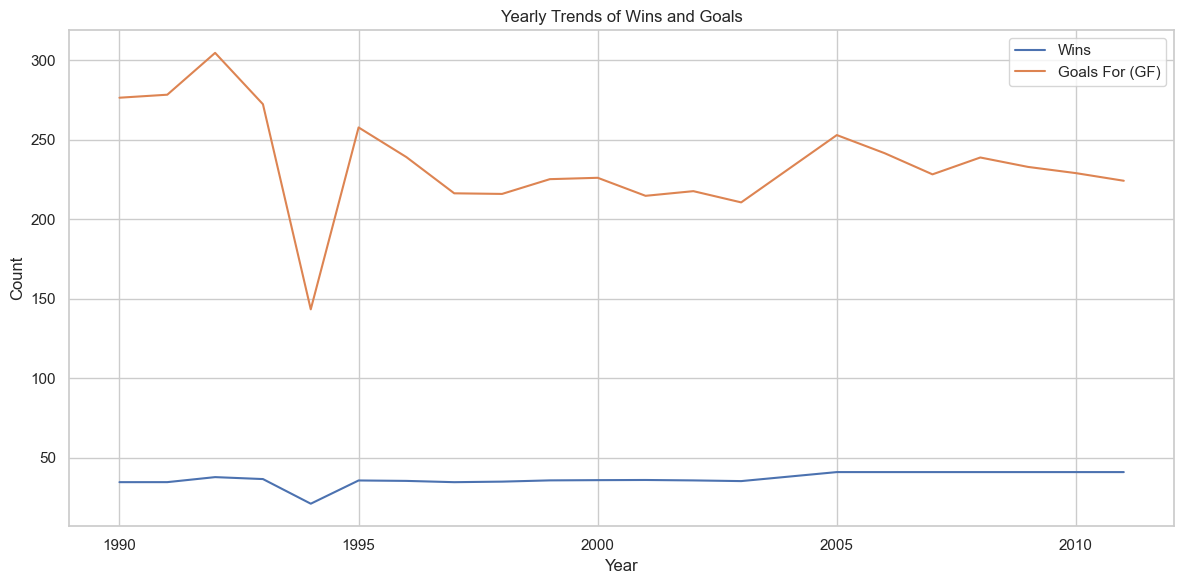

In [15]:
# Set style
sns.set(style="whitegrid")

# Ensure final folder exists
FINAL_DATA_PATH = os.path.join("..", "data", "final")
os.makedirs(FINAL_DATA_PATH, exist_ok=True)

# Yearly trends: Wins & Goals For (GF)
plt.figure(figsize=(12,6))
sns.lineplot(x='Year', y='Wins', data=df, ci=None, label='Wins')
sns.lineplot(x='Year', y='Goals For (GF)', data=df, ci=None, label='Goals For (GF)')
plt.title("Yearly Trends of Wins and Goals")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()

# Save plot safely
plt.savefig(os.path.join(FINAL_DATA_PATH, "yearly_trends.png"))
plt.show()

## Summary of EDA
- Wins distribution is slightly right-skewed.
- Goal Difference strongly correlates with Wins.
- Correlation heatmap shows relationships among numeric variables.
- Yearly trends highlight changes in Wins and Goals over seasons.
- All plots are saved in `data/final/` for reporting purposes.